https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction

# 1. Analyze the situation

all presents in the url above

# 2. Get the data

In [2]:
import pandas as pd

dataset = pd.read_csv("../../datasets/taxiprice.csv")

# 3. EDA AND PREPROCESSING

Detaisl:
1. 1000 samples, 11 features

Problemns:
1. Categorial features
2. Null values

#### 3.1 Geral visualize

In [3]:
dataset.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [4]:
dataset.shape

(1000, 11)

#### 3.2 STRUCTURE AND QUALITY OF FEATURES

In [5]:
# 3.2.1 CONSTANST FEATURE

dataset.nunique()

Trip_Distance_km         867
Time_of_Day                4
Day_of_Week                2
Passenger_Count            4
Traffic_Conditions         3
Weather                    3
Base_Fare                290
Per_Km_Rate              150
Per_Minute_Rate           41
Trip_Duration_Minutes    917
Trip_Price               951
dtype: int64

In [6]:
# 3.2.2 REDUDANT FEATURES

dataset.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [7]:
# 3.2.3 DUPLICATED

dataset.duplicated().sum()

np.int64(0)

In [8]:
# 3.2.3 CARDINALITY

dataset.nunique()

Trip_Distance_km         867
Time_of_Day                4
Day_of_Week                2
Passenger_Count            4
Traffic_Conditions         3
Weather                    3
Base_Fare                290
Per_Km_Rate              150
Per_Minute_Rate           41
Trip_Duration_Minutes    917
Trip_Price               951
dtype: int64

In [9]:
dataset.dropna(axis = 0, inplace= True)
print(dataset.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


#### 3.3 TYPE OF DATA

In [10]:
dataset.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

In [11]:
# OBJECT DATA TREAT
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# NOMINAL

one_hot = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

nominal_features = ['Time_of_Day', 'Day_of_Week', 'Weather']
dataset = pd.get_dummies(dataset, columns=nominal_features, drop_first=True, dtype= int)


# ORDINAL
ordinal = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
dataset['Traffic_Conditions'] = ordinal.fit_transform(dataset[['Traffic_Conditions']])
dataset.head()


,Trip_Distance_km,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
0,19.35,3.0,0.0,3.56,0.80,0.32,53.82,36.2624,0,1,0,0,0,0
2,36.87,1.0,2.0,2.70,1.21,0.15,37.27,52.9032,1,0,0,1,0,0
5,8.64,2.0,1.0,2.55,1.71,0.48,89.33,60.2028,0,0,0,1,0,0
12,41.79,3.0,2.0,4.60,1.77,0.11,86.95,88.1328,0,0,1,1,0,0
14,9.91,2.0,2.0,2.32,1.26,0.34,41.72,28.9914,1,0,0,0,0,0


In [12]:
dataset.dtypes

Trip_Distance_km         float64
Passenger_Count          float64
Traffic_Conditions       float64
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
Time_of_Day_Evening        int64
Time_of_Day_Morning        int64
Time_of_Day_Night          int64
Day_of_Week_Weekend        int64
Weather_Rain               int64
Weather_Snow               int64
dtype: object

#### 3.4 MISSING AND INVALID DATA

In [13]:
# 3.4.1 Negative data

print((dataset < 0).sum().sum())

0


#### 3.5 DISTRIBUTION OF DATA

In [14]:
# 3.4.2 SKEWED DATA

dataset.skew()

Trip_Distance_km         2.463040
Passenger_Count         -0.018680
Traffic_Conditions       0.326594
Base_Fare               -0.006657
Per_Km_Rate              0.144746
Per_Minute_Rate          0.124094
Trip_Duration_Minutes    0.009990
Trip_Price               3.771449
Time_of_Day_Evening      1.350963
Time_of_Day_Morning      0.986134
Time_of_Day_Night        2.523658
Day_of_Week_Weekend      0.763642
Weather_Rain             1.230934
Weather_Snow             3.243121
dtype: float64

In [15]:
# SKEWED TREAT DATA
# TRIP_DISTANCIE_KM // TRIP_PRICE
import numpy as np

dataset['Trip_Distance_km'] = np.log1p(dataset['Trip_Distance_km'])
dataset['Trip_Price'] = np.log1p(dataset['Trip_Price'])

dataset.skew()

Trip_Distance_km        -0.672480
Passenger_Count         -0.018680
Traffic_Conditions       0.326594
Base_Fare               -0.006657
Per_Km_Rate              0.144746
Per_Minute_Rate          0.124094
Trip_Duration_Minutes    0.009990
Trip_Price               0.068252
Time_of_Day_Evening      1.350963
Time_of_Day_Morning      0.986134
Time_of_Day_Night        2.523658
Day_of_Week_Weekend      0.763642
Weather_Rain             1.230934
Weather_Snow             3.243121
dtype: float64

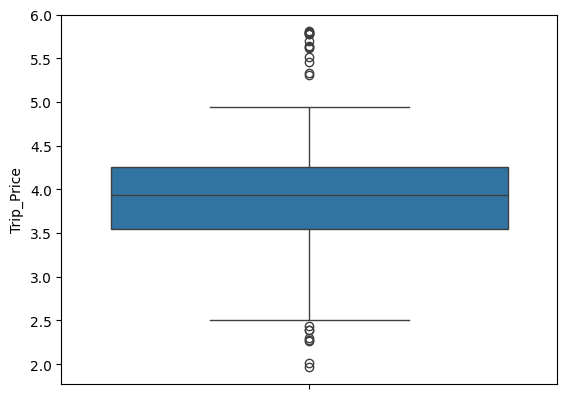

In [16]:
# 3.5.2 OUTLIERS

import seaborn as sns
sns.boxplot(dataset['Trip_Price']);

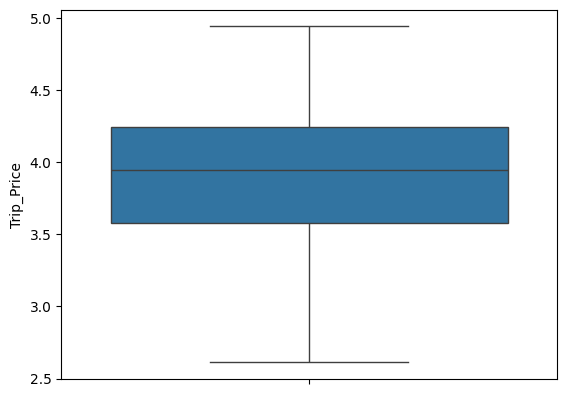

In [17]:
# TREAT OUTLIERS

num_cols = ['Trip_Distance_km', 'Trip_Price', 'Trip_Duration_Minutes'] 
for col in num_cols:
    Q1 = dataset[col].quantile(0.26)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    dataset = dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]

sns.boxplot(dataset['Trip_Price']);

#### 3.6 DISTRIBUTION OF DATA

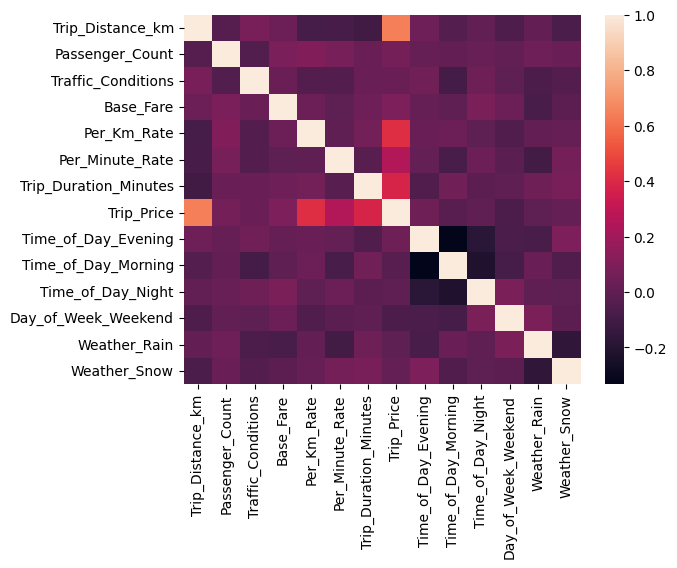

In [18]:
correlation = dataset.corr()
sns.heatmap(correlation);

In [19]:
dataset.describe()

,Trip_Distance_km,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,3.118173,2.558712,0.784091,3.518788,1.226004,0.289716,62.673826,3.894474,0.219697,0.282197,0.109848,0.318182,0.242424,0.075758
std,0.671293,1.105601,0.722879,0.872065,0.426062,0.115833,31.980186,0.458971,0.414434,0.450496,0.312997,0.466212,0.428956,0.264861
min,1.190888,1.000000,0.000000,2.010000,0.500000,0.100000,5.010000,2.612009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.725720,2.000000,0.000000,2.727500,0.857500,0.190000,37.805000,3.574842,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.313640,3.000000,1.000000,3.545000,1.200000,0.280000,62.035000,3.946279,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.671987,4.000000,1.000000,4.270000,1.580000,0.390000,89.625000,4.240786,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,3.931630,4.000000,2.000000,5.000000,2.000000,0.500000,119.840000,4.939086,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# SPLIT DATA AND PREPROCESSING (SCALE AWARENESS)

In [20]:
X = dataset.drop(columns=['Trip_Price'])
y = dataset[['Trip_Price']]
X.head()

,Trip_Distance_km,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Weather_Rain,Weather_Snow
0,3.013081,3.0,0.0,3.56,0.80,0.32,53.82,0,1,0,0,0,0
2,3.634159,1.0,2.0,2.70,1.21,0.15,37.27,1,0,0,1,0,0
5,2.265921,2.0,1.0,2.55,1.71,0.48,89.33,0,0,0,1,0,0
12,3.756304,3.0,2.0,4.60,1.77,0.11,86.95,0,0,1,1,0,0
14,2.389680,2.0,2.0,2.32,1.26,0.34,41.72,1,0,0,0,0,0


In [21]:
X.shape

(528, 13)

In [22]:
y.head()

,Trip_Price
0,3.617985
2,3.987190
5,4.114193
12,4.490127
14,3.400911


In [23]:
y.shape

(528, 1)

# SPLIT AND PREPROCESSING 2

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SPLIT THE DATA
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 49)

# SCALING THE DATA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
Y_train_scaled = scaler.fit_transform(Y_train)
x_test_scaled = scaler.fit_transform(x_test)
y_test_scaled = scaler.fit_transform(y_test)


# FIT THE MODEL AND ACCURACY

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# FIT THE MODEL
model = LinearRegression()
model.fit(X_train_scaled, Y_train_scaled)

# PREDICT AND ACCURACY OF THE TRAIN PART
y_preds_train = model.predict(X_train_scaled)
r2_train = r2_score(Y_train_scaled, y_preds_train)
print(f"The accuracy of train part r2 was: {r2_train*100:.2f}")


# PREDICT AND ACCURACY OF THE TEST PART
y_preds_test = model.predict(x_test_scaled)
r2_test = r2_score(y_test_scaled, y_preds_test)
print(f"The accuracy of test part r2 was: {r2_test*100:.2f}")


The accuracy of train part r2 was: 90.95
The accuracy of test part r2 was: 90.47
